In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from jetnet.datasets import JetNet

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

plt.rcParams["text.usetex"] = True
sns.set_palette("deep")

In [24]:
MASK = True
NUM_PARTICLES = 30
TRAIN_SPLIT = 0.7
JET_FEATURES = ["eta", "pt", "mass", "num_particles", "type"]

data_args = {
    "jet_type": ["g", "q", "t", "w", "z"],
    "data_dir": "datasets/jetnet",
    "num_particles": 150,
    # Don't need particle features for this notebk
    "particle_features": (
        # JetNet.ALL_PARTICLE_FEATURES if MASK else JetNet.ALL_PARTICLE_FEATURES[:-1]
    ),
    # The order of the list is preserved in the retrieved data
    "jet_features": JET_FEATURES,
    # "particle_normalisation": particle_normalizer,
    "split_fraction": [TRAIN_SPLIT, 1 - TRAIN_SPLIT, 0],
    "download": True
}
X_train = JetNet(**data_args, split="train")
X_test = JetNet(**data_args, split="valid")

X_train = X_train[:][1]
X_test = X_test[:][1]

Text(0.5, 1.0, 'Jet type distribution in training set')

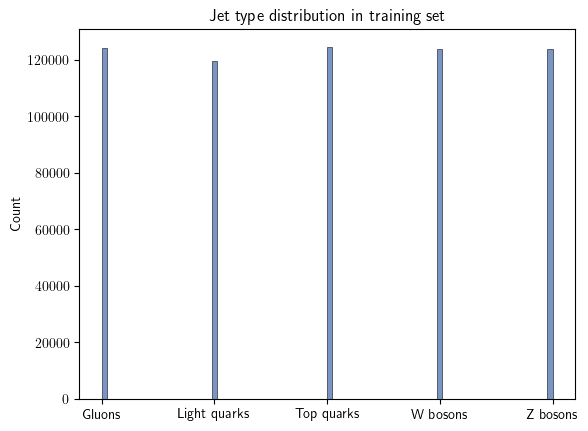

In [25]:
jet_type_map = {
    0: "Gluons",
    1: "Light quarks",
    2: "Top quarks",
    3: "W bosons",
    4: "Z bosons"
}
sns.histplot(X_train[:, -1].numpy())
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=jet_type_map.values())
# plt.xlabel("Jet Type")
plt.ylabel("Count")
plt.title("Jet type distribution in training set")

In [26]:
X_train[X_train[:, -1] == 0].shape

torch.Size([124135, 5])

In [27]:
# get 5 colors from the set2 palette
colors = sns.color_palette("deep", 5)
colors

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254)]

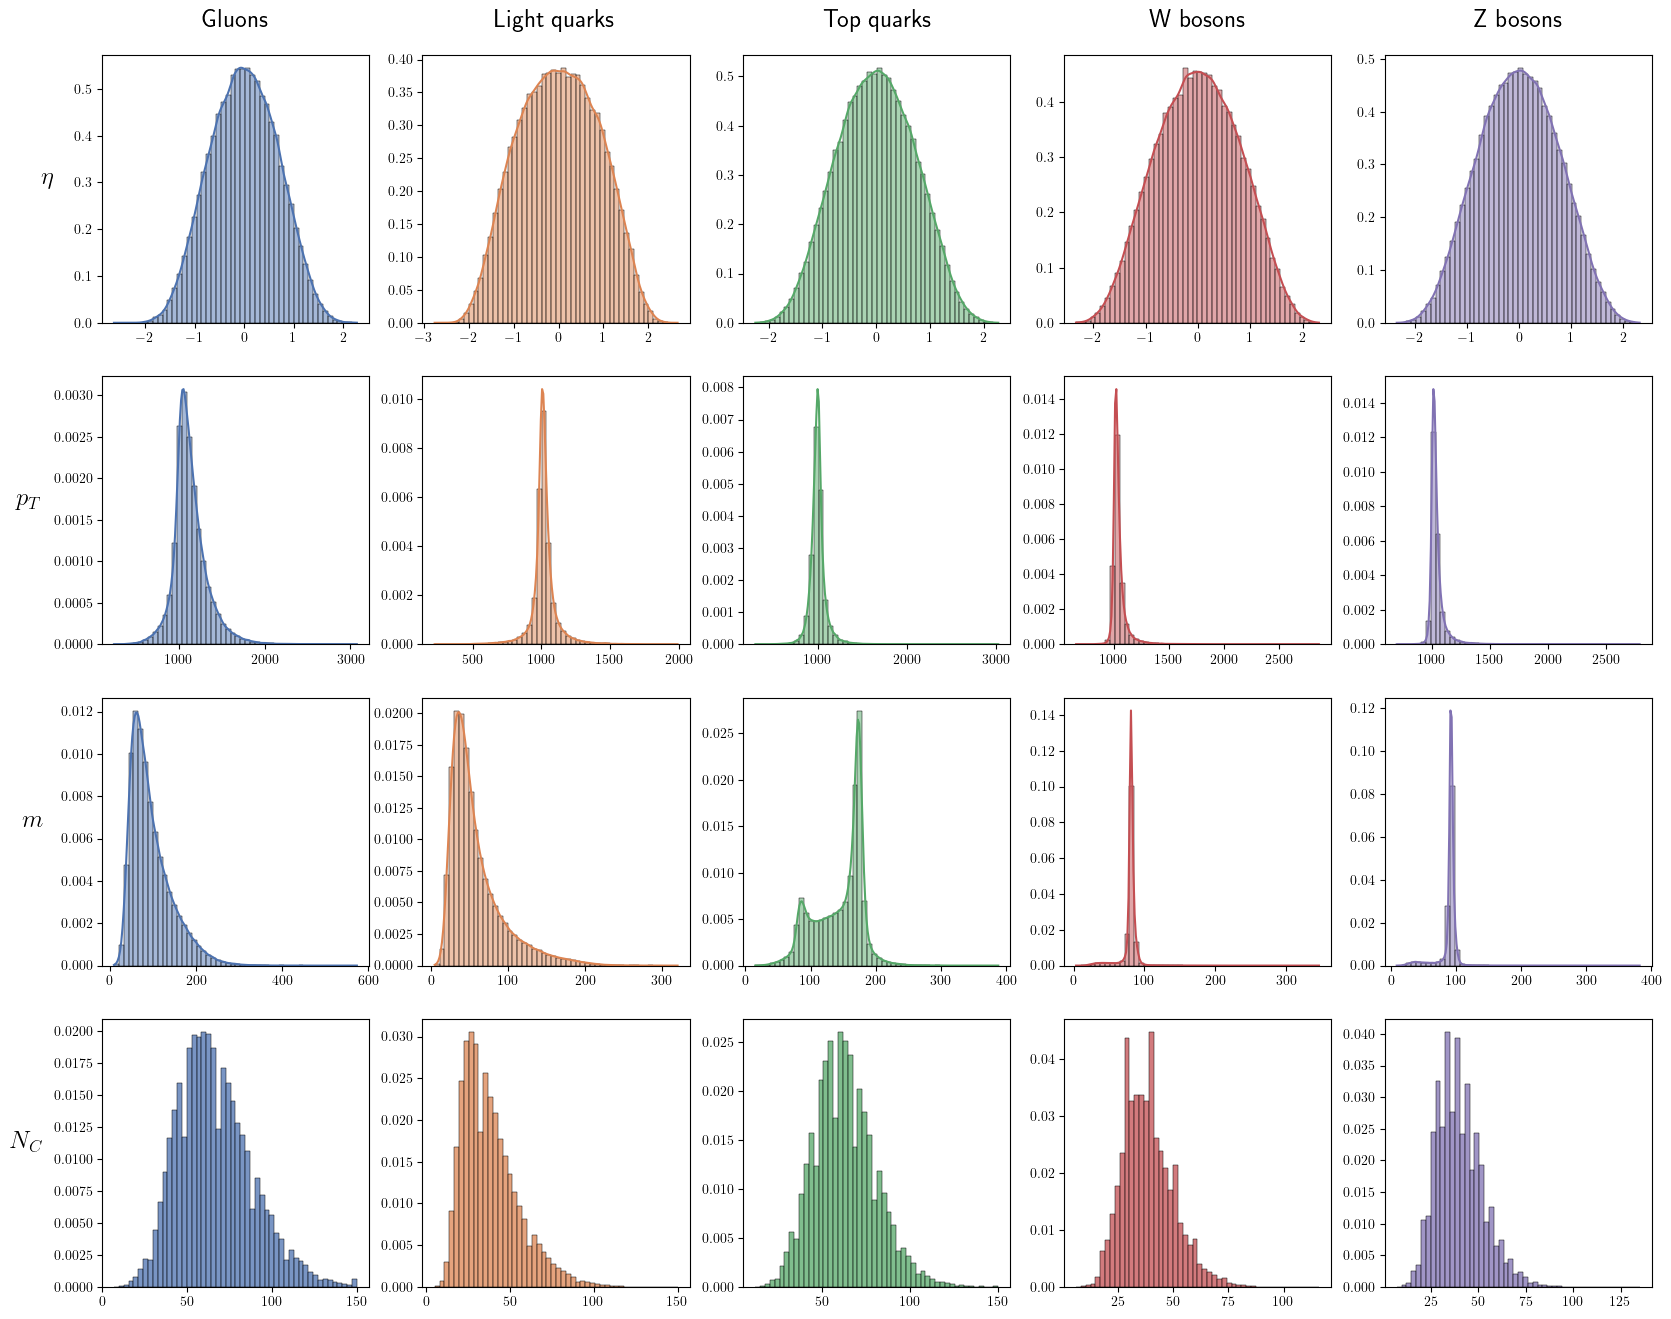

In [28]:
JET_FEATURES = [r"$\eta$", r"$p_T$", r"$m$", r"$N_C$"]

fig, axs = plt.subplots(4, 5, figsize=(20, 16))


for i, feature in enumerate(JET_FEATURES):
    for j, jet_type in enumerate(jet_type_map.keys()):
        if i == 0:
            axs[i, j].set_title(jet_type_map[jet_type], fontsize=18, pad=20)
        else:
            axs[i, j].set_title("")
        ax = axs[i, j]
        sns.histplot(
            X_train[X_train[:, -1] == jet_type][:, i].numpy(),
            ax=ax,
            kde=feature != r"$N_C$",
            stat="density",
            bins=50,
            color=colors[j],
        )
        ax.set_xlabel("")
        ax.set_ylabel("")
    axs[i, 0].set_ylabel(feature, rotation=0, fontsize=18, labelpad=20)

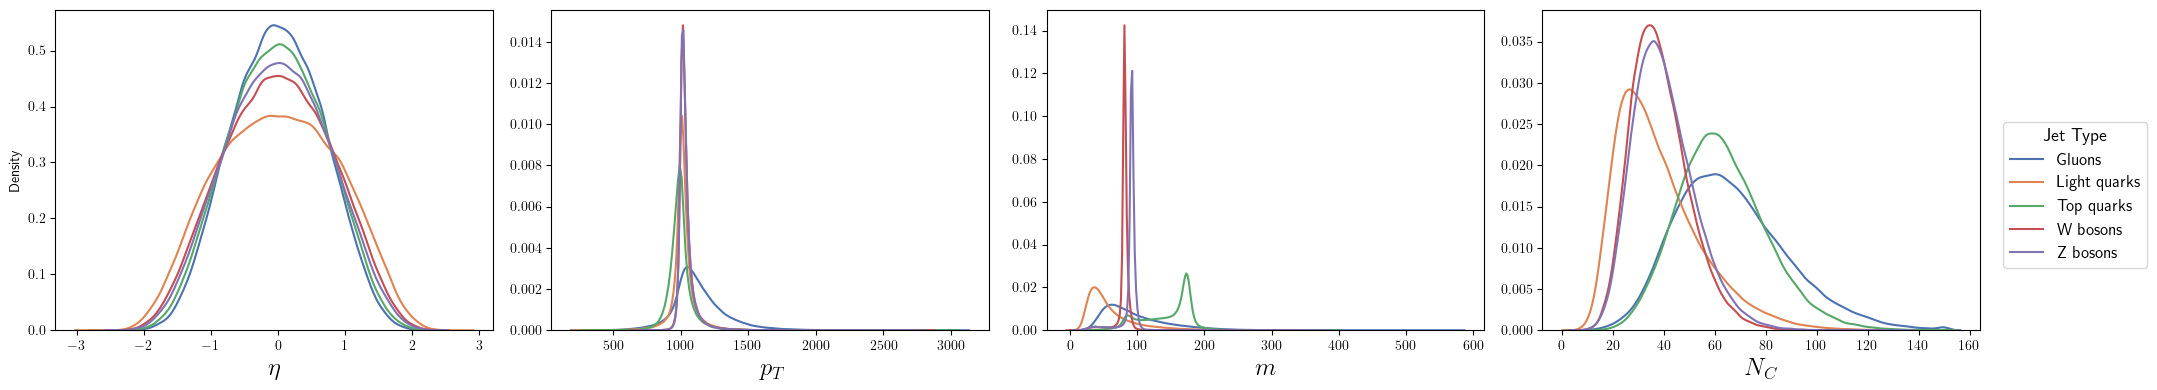

In [ ]:

fig, axs = plt.subplots(1, 4, figsize=(20, 4))
for i, feature in enumerate(JET_FEATURES):
    ax = axs[i]
    for jet_type in jet_type_map.keys():
        sns.kdeplot(
            X_train[X_train[:, -1] == jet_type][:, i].numpy(),
            ax=ax,
            label=jet_type_map[jet_type]
        )
    ax.set_xlabel(feature, fontsize=18)
    if i == 0:
        ax.set_ylabel("Density")
    else:
        ax.set_ylabel("")
legend_handles, legend_labels = axs[0].get_legend_handles_labels()
fig.legend(
    legend_handles,
    legend_labels,
    title="Jet Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title_fontsize=13
)
plt.tight_layout()
plt.savefig("gen/figs/real_jet_attributes.png", dpi=300, bbox_inches="tight")

We will train a normalizing flow conditioned on jet type that generates the jet $\eta$-coordinate, jet transverse momentum $p_T$, jet mass $m$, and the number of particles $N$.

In [30]:
def one_hot_enc_jet_type(y, num_classes=5):
    """
    One-hot encode the jet type labels.
    
    Args:
        y (torch.Tensor): Tensor of jet type labels.
        num_classes (int): Number of classes for one-hot encoding.
        
    Returns:
        torch.Tensor: One-hot encoded tensor.
    """
    one_hot_enc =  torch.nn.functional.one_hot(y, num_classes=num_classes).float()
    noise = torch.randn_like(one_hot_enc) * 0.01
    one_hot_enc += noise
    return one_hot_enc

def one_hot_to_type(one_hot_types):
    """
    Convert one-hot encoded jet types back to class labels.
    
    Args:
        one_hot_types (torch.Tensor): One-hot encoded tensor of jet types.
        
    Returns:
        torch.Tensor: Class labels for the jet types.
    """
    return torch.argmax(one_hot_types, dim=1)

long_types = X_train[:, -1].long()
one_hot_jets = one_hot_enc_jet_type(long_types)
print(one_hot_jets.shape, one_hot_jets.sum(dim=0))

torch.Size([616000, 5]) tensor([124132.2500, 119466.4531, 124562.5859, 123829.6797, 123990.5000])


In [31]:
import normflows as nf
from tqdm.notebook import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [32]:
K = 4

latent_size = 4
context_size = 5
hidden_units = 128
hidden_layers = 6

flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units, num_context_channels=context_size)]
    flows += [nf.flows.LULinearPermute(latent_size)]

q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)
model = nf.ConditionalNormalizingFlow(q0, flows).to(device)
model

ConditionalNormalizingFlow(
  (q0): DiagGaussian()
  (flows): ModuleList(
    (0): AutoregressiveRationalQuadraticSpline(
      (mprqat): MaskedPiecewiseRationalQuadraticAutoregressive(
        (autoregressive_net): MADE(
          (preprocessing): Identity()
          (initial_layer): MaskedLinear(in_features=4, out_features=128, bias=True)
          (context_layer): Linear(in_features=5, out_features=128, bias=True)
          (blocks): ModuleList(
            (0-5): 6 x MaskedResidualBlock(
              (context_layer): Linear(in_features=5, out_features=128, bias=True)
              (linear_layers): ModuleList(
                (0-1): 2 x MaskedLinear(in_features=128, out_features=128, bias=True)
              )
              (activation): ReLU()
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (final_layer): MaskedLinear(in_features=128, out_features=92, bias=True)
        )
      )
    )
    (1): LULinearPermute(
      (permutation): _Rand

  0%|          | 0/25000 [00:00<?, ?it/s]

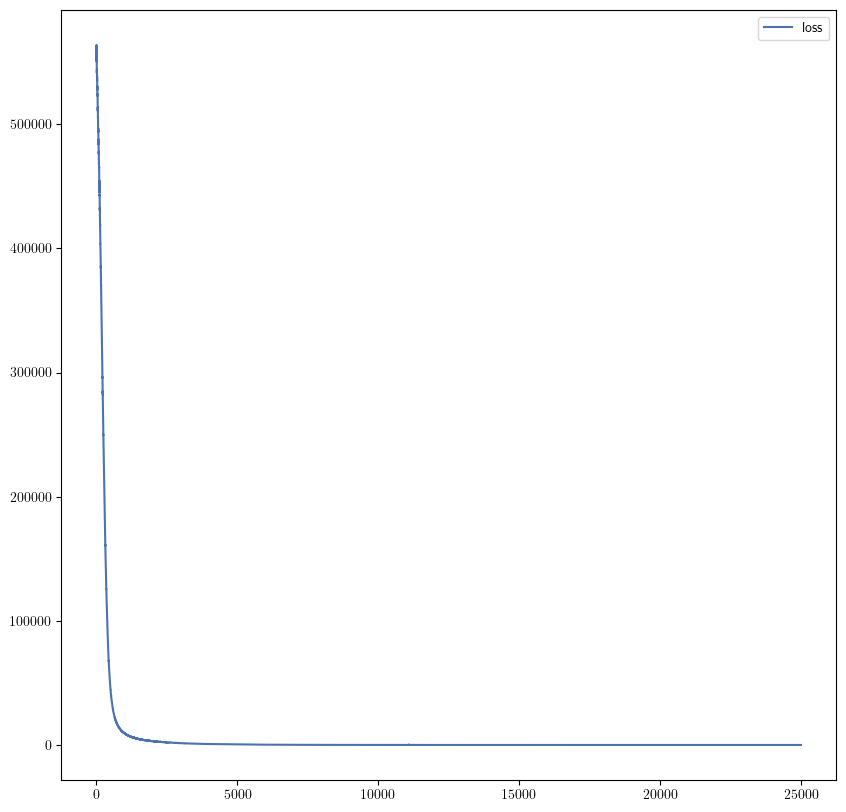

In [33]:
max_iter = 25_000
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
batch_size = 4096

loss_hist = np.array([])
for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    indices = torch.randperm(len(X_train))[:batch_size]
    jets = X_train[indices]
    jet_info = jets[:, :-1].to(device)  # Exclude the jet type column
    jet_types = jets[:, -1].long().to(device)  # Get the jet type column
    one_hot_types = one_hot_enc_jet_type(jet_types).to(device)
    
    # Compute loss
    loss = model.forward_kld(jet_info, one_hot_types)

    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

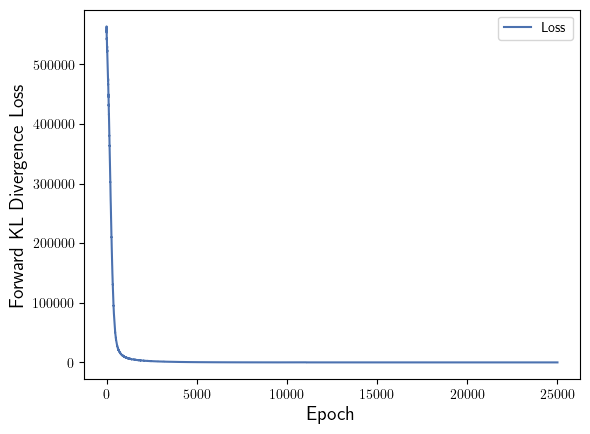

In [82]:
sns.set_palette("deep")
sns.lineplot(
    x=np.arange(len(loss_hist)),
    y=loss_hist,
    label="Loss",
)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Forward KL Divergence Loss", fontsize=14)
plt.savefig("gen/figs/jet_attr_nf_loss.png", dpi=300, bbox_inches="tight")

In [52]:
model.eval()
n_samples = 50_000
sample_jet_types = torch.randint(0, 5, (n_samples,)).to(device)
one_hot_types = one_hot_enc_jet_type(sample_jet_types)
print(one_hot_types.shape, one_hot_types.sum(dim=0))

torch.Size([50000, 5]) tensor([10046.5801,  9940.0479,  9992.2949,  9959.2764, 10061.4854])


In [53]:
sample_vals, sample_logprobs = model.sample(n_samples, context=one_hot_types)
sample_jet_types.shape, sample_vals.shape, sample_logprobs.shape

(torch.Size([50000]), torch.Size([50000, 4]), torch.Size([50000]))

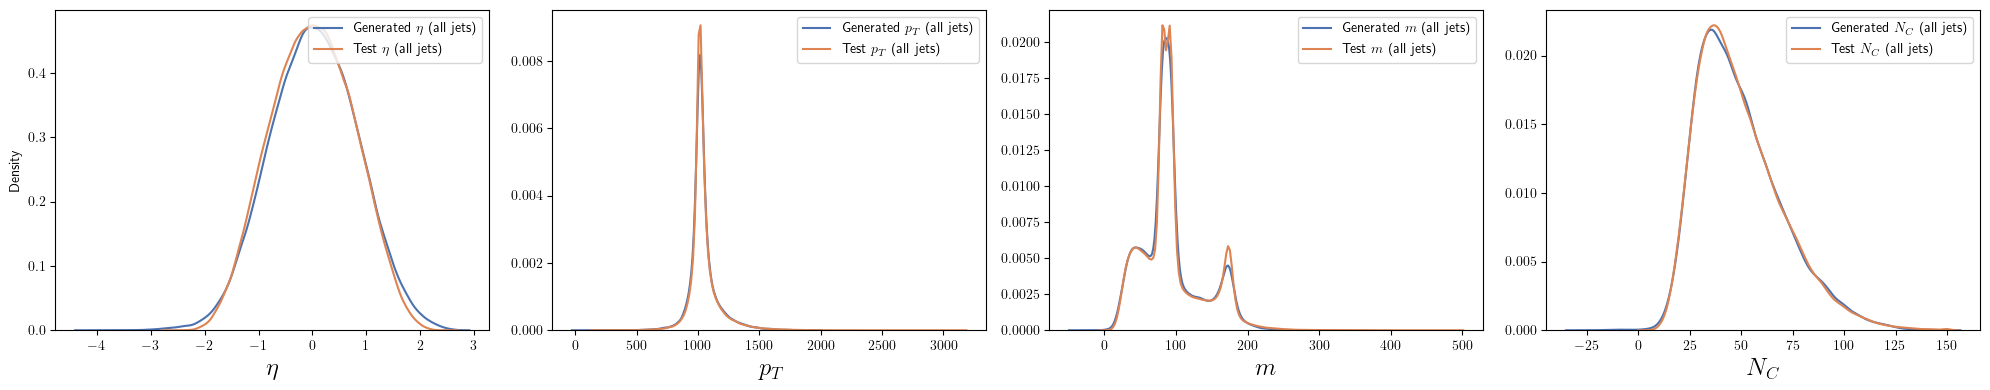

In [83]:
fig, axs = plt.subplots(1, 4, figsize=(20, 4))
for i, feature in enumerate(JET_FEATURES):
    ax = axs[i]
    sns.kdeplot(
        sample_vals[:, i].detach().numpy(),
        ax=ax,
        label=r"Generated " + feature + r" (all jets)",
    )
    sns.kdeplot(
        X_test[:, i].numpy(),
        ax=ax,
        label=r"Test " + feature + r" (all jets)",
    )
    ax.set_xlabel(feature, fontsize=18)
    if i == 0:
        ax.set_ylabel("Density")
    else:
        ax.set_ylabel("")
    ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("gen/figs/jet_attr_nf_sampled_all_features.png", dpi=300, bbox_inches="tight")


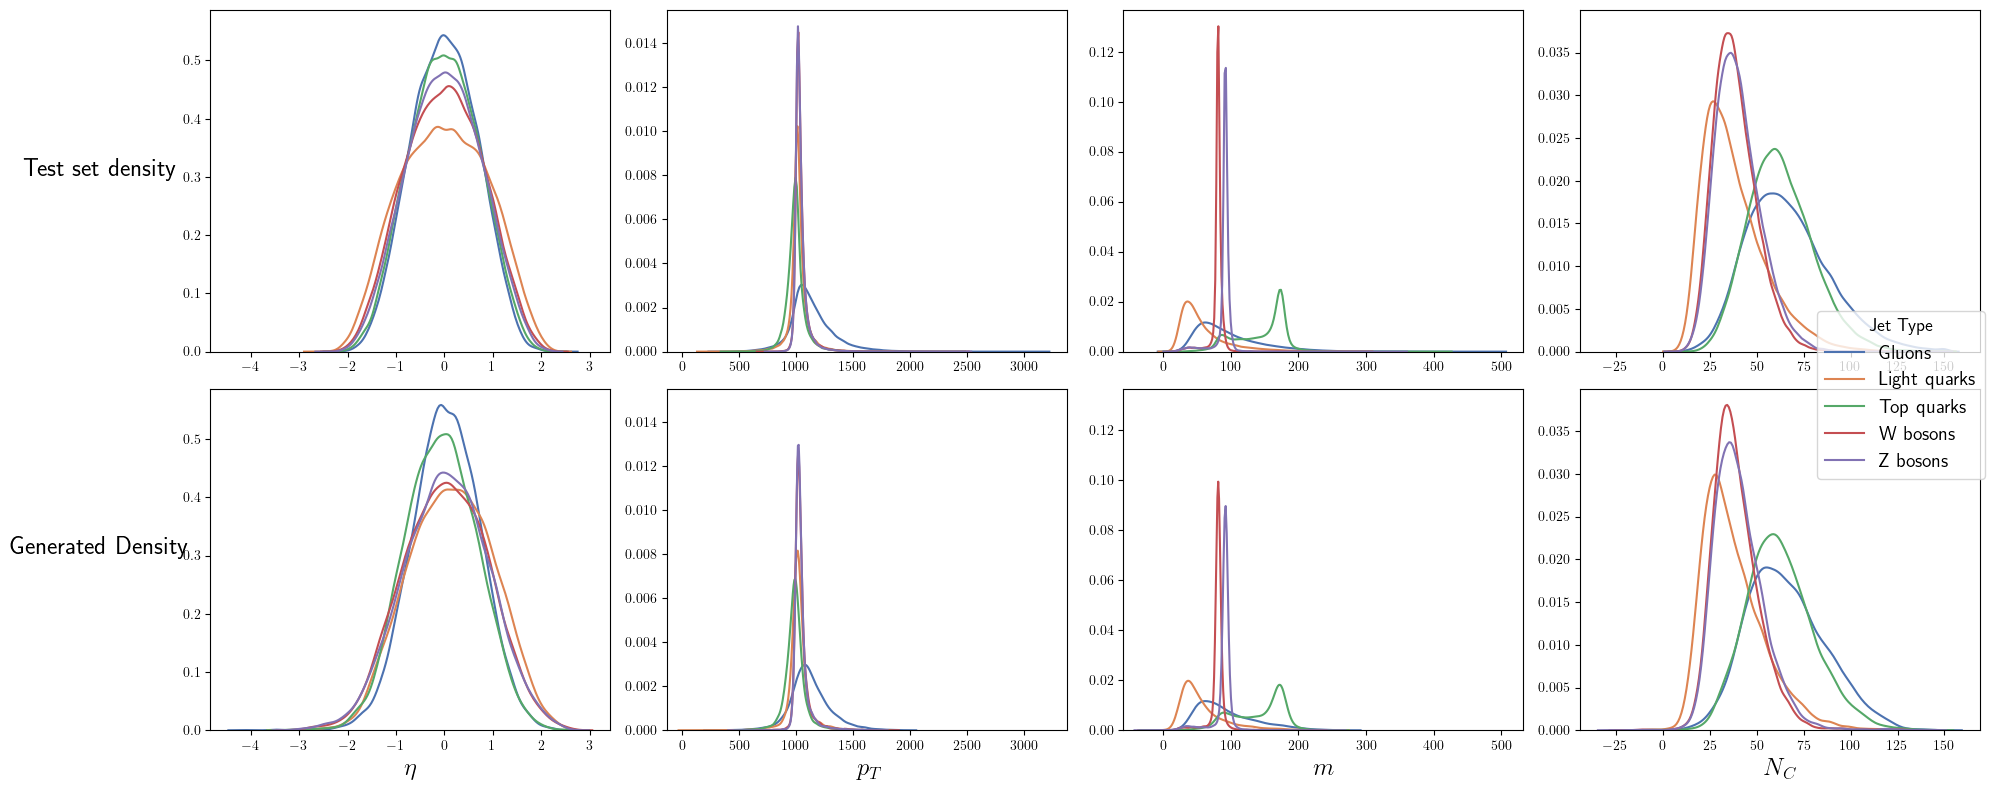

In [84]:
fig, axs = plt.subplots(2, 4, figsize=(20, 8))
for i, feature in enumerate(JET_FEATURES):
    ax = axs[0, i]
    for jet_type in jet_type_map.keys():
        sns.kdeplot(
            X_test[X_test[:, -1] == jet_type][:, i].numpy(),
            ax=ax,
            label=jet_type_map[jet_type]
        )
    # ax.set_xlabel(feature, fontsize=18)
    if i == 0:
        ax.set_ylabel("Test set density", fontsize=18, rotation=0, labelpad=60)
    else:
        ax.set_ylabel("")

    ax = axs[1, i]
    for jet_type in jet_type_map.keys():
        sns.kdeplot(
            sample_vals[sample_jet_types == jet_type][:, i].detach().numpy(),
            ax=ax,
            label=jet_type_map[jet_type]
        )
    ax.set_xlabel(feature, fontsize=18)
    if i == 0:
        ax.set_ylabel("Generated Density", fontsize=18, rotation=0, labelpad=60)
    else:
        ax.set_ylabel("")

for i in range(4):
    ax1 = axs[0, i]
    ax2 = axs[1, i]

    # Get combined x and y limits for both axes
    xlims = np.array([ax1.get_xlim(), ax2.get_xlim()])
    ylims = np.array([ax1.get_ylim(), ax2.get_ylim()])

    # Set both axes to have the same limits
    xlim_combined = (xlims[:, 0].min(), xlims[:, 1].max())
    ylim_combined = (ylims[:, 0].min(), ylims[:, 1].max())

    ax1.set_xlim(xlim_combined)
    ax2.set_xlim(xlim_combined)
    ax1.set_ylim(ylim_combined)
    ax2.set_ylim(ylim_combined)


legend_handles, legend_labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    legend_handles,
    legend_labels,
    title="Jet Type",
    loc="center right",
    bbox_to_anchor=(1, 0.5),
    fontsize=14,
    title_fontsize=13
)
plt.tight_layout()
plt.savefig("gen/figs/jet_attr_nf_sampled_jet_type.png", dpi=300, bbox_inches="tight")

In [85]:
from jetnet.evaluation import fpd

In [91]:
fpd_val, fpd_err = fpd(
    real_features=X_test[:, :-1].numpy(),
    gen_features=sample_vals.detach().numpy(),
    seed=RANDOM_SEED
)
print(f"FPD: {fpd_val:.5E} ± {fpd_err:.5E}")
with open("gen/logs/jet_attr_nf_fpd.txt", "w") as f:
    f.write(f"FPD: {fpd_val:.5E} ± {fpd_err:.5E}\n")
    f.write(f"Seed: {RANDOM_SEED}\n")
    f.write(f"Number of samples: {n_samples}\n")
    f.write(f"Batch size: {batch_size}\n")
    f.write(f"Hidden units: {hidden_units}\n")
    f.write(f"Hidden layers: {hidden_layers}\n")
    f.write(f"Latent size: {latent_size}\n")
    f.write(f"Number of flows: {K}\n")
    f.write(f"Max iterations: {max_iter}\n")
    f.write(f"Train split: {TRAIN_SPLIT}\n")
    f.close()

FPD: 6.63179E-04 ± 3.57648E-05
